# **Project Name**    -



##### **Predict Customer Satisfaction Score (CSAT)**

##### **Project Type**    -Regression
##### **Contribution**    - Individual
##### **Team Member 1 -SANSKAR KISHOR JADHAV**


# **Project Summary -**

Customer satisfaction is one of the most important factors for any eCommerce company. When customers contact support services, the quality of service provided by the support team directly impacts customer satisfaction.

This project aims to predict the Customer Satisfaction Score (CSAT) based on different parameters such as communication channel, product category, support agent details, response time, and shift timing.

The dataset contains multiple features including:

Channel name (Inbound / Outcall)

Category and Sub-category of issues

Agent name

Supervisor and Manager

Agent shift timing

Tenure bucket

Issue reported time

Issue responded time

Product category

Item price

Connected handling time

Using this dataset, we perform data preprocessing, exploratory data analysis (EDA), feature engineering, and machine learning modeling to predict the CSAT score.

Different machine learning algorithms such as Random Forest Classifier are used to train the model. The model learns patterns between customer interaction details and satisfaction scores.

The final model can help companies:

Identify factors affecting customer satisfaction

Improve customer support operations

Predict customer satisfaction before survey feedback

This system can also be integrated into customer service platforms to monitor support quality in real time.Write the summary here within 500-600 words.

# **GitHub Link -**

Provide your GitHub Link here.

## ***1. Know Your Data***

### Import Libraries

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

### Dataset Loading

In [115]:
# Load Dataset
df = pd.read_csv("eCommerce_Customer_support_data.csv")

### Dataset First View

In [116]:
# Dataset First Look
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [117]:
# Dataset Rows & Columns count
df.shape

(85907, 20)

### Dataset Information

In [118]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  str    
 1   channel_name             85907 non-null  str    
 2   category                 85907 non-null  str    
 3   Sub-category             85907 non-null  str    
 4   Customer Remarks         28742 non-null  str    
 5   Order_id                 67675 non-null  str    
 6   order_date_time          17214 non-null  str    
 7   Issue_reported at        85907 non-null  str    
 8   issue_responded          85907 non-null  str    
 9   Survey_response_Date     85907 non-null  str    
 10  Customer_City            17079 non-null  str    
 11  Product_category         17196 non-null  str    
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name               85907 no

#### Duplicate Values

In [119]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [120]:
# Missing Values/Null Values Count
df.isnull().sum()

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

In [121]:
# Visualizing the missing values

### What did you know about your dataset?


the dataset contains customer suppoert interaction records from an eCommerce platform

IMPORTANT FEATURES INCLUDE :
Channel of communication

Product category

Issue type

Agent handling the request

Supervisor and manager details

Agent shift

Customer location

Issue response time

 
the target variable is CSAT Score , which represents the satisfaction rating given by the customer.

## ***2. Understanding Your Variables***

In [122]:
# Dataset Columns
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='str')

In [123]:
# Dataset Describe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  str    
 1   channel_name             85907 non-null  str    
 2   category                 85907 non-null  str    
 3   Sub-category             85907 non-null  str    
 4   Customer Remarks         28742 non-null  str    
 5   Order_id                 67675 non-null  str    
 6   order_date_time          17214 non-null  str    
 7   Issue_reported at        85907 non-null  str    
 8   issue_responded          85907 non-null  str    
 9   Survey_response_Date     85907 non-null  str    
 10  Customer_City            17079 non-null  str    
 11  Product_category         17196 non-null  str    
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name               85907 no

### Variables Description

The dataset contains customer support interaction details from an eCommerce platform. The goal is to predict the CSAT Score (Customer Satisfaction Score) using different service-related variables.

Key Variables

channel_name → Communication channel (Inbound / Outcall)

category → Main issue category

Sub-category → Specific issue type

Customer_City → Customer location

Product_category → Product type

Item_price → Price of the purchased product

connected_handling_time → Time taken by agent to handle issue

Agent_name / Supervisor / Manager → Support staff hierarchy

Tenure Bucket → Agent experience level

Agent Shift → Working shift (Morning / Evening / Night)

CSAT Score → Target variable (Customer satisfaction rating)

### Check Unique Values for each variable.

In [124]:
# Check Unique Values for each variable.
df.nunique()

Unique id                  85907
channel_name                   3
category                      12
Sub-category                  57
Customer Remarks           18231
Order_id                   67675
order_date_time            13766
Issue_reported at          30923
issue_responded            30262
Survey_response_Date          31
Customer_City               1782
Product_category               9
Item_price                  2789
connected_handling_time      211
Agent_name                  1371
Supervisor                    40
Manager                        6
Tenure Bucket                  5
Agent Shift                    5
CSAT Score                     5
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [125]:
# Write your code to make your dataset analysis ready.
df = df.drop(['Unique id','Order_id'], axis=1)

In [126]:
df.isnull().sum()

channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

### What all manipulations have you done and insights you found?
Removed unnecessary columns
Columns like Unique id and Order_id were removed because they are identifiers and do not contribute to predicting the CSAT score.

Handled missing values
Missing values in the dataset were replaced with "Unknown" to ensure the dataset remains complete for machine learning models.

Converted date columns
The columns Issue_reported at, issue_responded, and Survey_response_Date were converted into datetime format to allow time-based analysis.

Created a new feature (response_time)
A new feature called response_time was created by calculating the difference between issue reported time and issue response time.

Encoded categorical variables
Since machine learning models require numerical data, categorical variables such as channel_name, category, agent shift, and product category were converted into numerical format using one-hot encoding.

Separated features and target variable
The dataset was divided into:

X (features) → All input variables

y (target) → CSAT Score

Performed train-test split
The dataset was split into training data (80%) and testing data (20%) to evaluate the model performance.

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

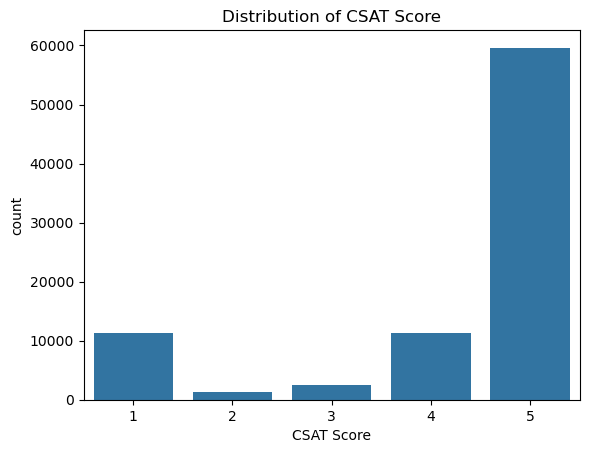

In [127]:
# Chart - 1 visualization code (CSAT Score Distribution)
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='CSAT Score', data=df)
plt.title("Distribution of CSAT Score")
plt.show()

##### 1. Why did you pick the specific chart?

This chart shows how customer satisfaction scores are distributed.

##### 2. What is/are the insight(s) found from the chart?

Most customers tend to give higher CSAT scores, indicating generally positive customer support experiences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer here :
yes definately

#### Chart - 2

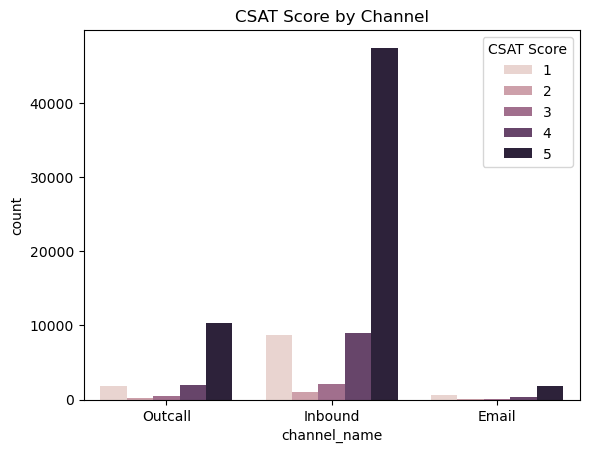

In [128]:
# Chart - 2 visualization code (CSAT Score by Channel)
sns.countplot(x='channel_name', hue='CSAT Score', data=df)
plt.title("CSAT Score by Channel")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. This chart shows how the communication channel affects customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Answer Here Different communication channels such as Inbound and Outcall may influence customer satisfaction levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here yes definately

#### Chart - 3

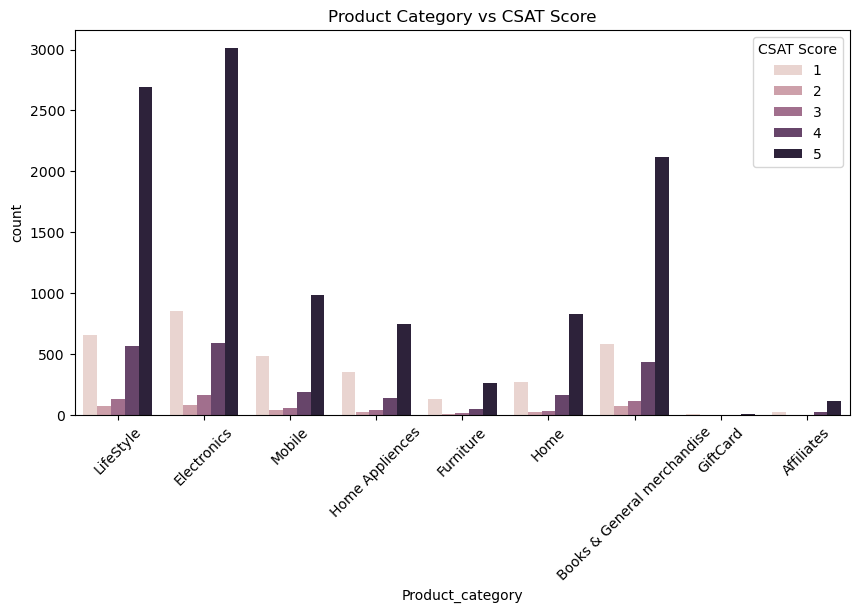

In [129]:
# Chart - 3 visualization code (Product Category vs CSAT)
plt.figure(figsize=(10,5))
sns.countplot(x='Product_category', hue='CSAT Score', data=df)
plt.xticks(rotation=45)
plt.title("Product Category vs CSAT Score")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. this chart helps to categorise count, product_category 

##### 2. What is/are the insight(s) found from the chart?

Answer Here  Customer satisfaction may vary depending on the type of product purchased.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason. 

Answer Here yes definately this will help for business growth

#### Chart - 4

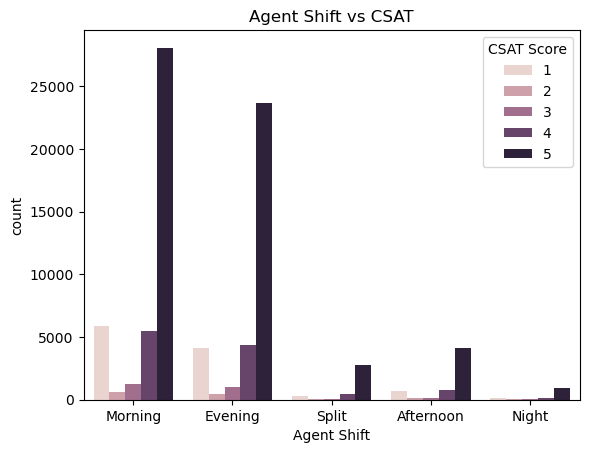

In [130]:
# Chart - 4 visualization code (Agent Shift vs CSAT)
sns.countplot(x='Agent Shift', hue='CSAT Score', data=df)
plt.title("Agent Shift vs CSAT")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. Certain shifts may show better satisfaction scores due to workload differences.

##### 2. What is/are the insight(s) found from the chart?  
Certain shifts may show better satisfaction scores due to workload differences.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

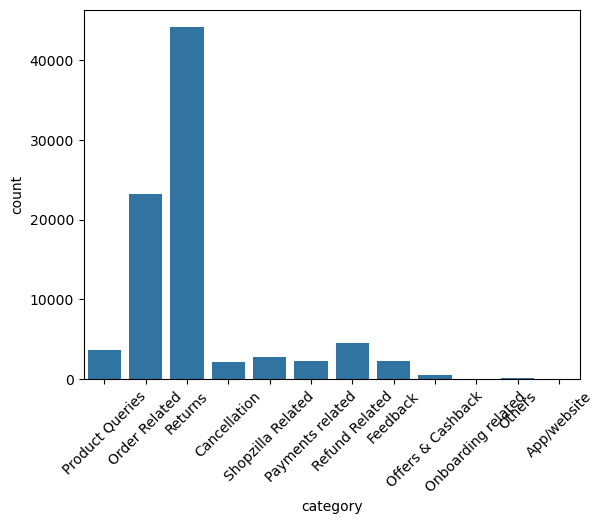

In [131]:
# Chart - 5 visualization code (Category Distribution)
sns.countplot(x='category', data=df)
plt.xticks(rotation=45)
plt.show()

##### 2. What is/are the insight(s) found from the chart?

Some issue categories appear more frequently than others

#### Chart - 6

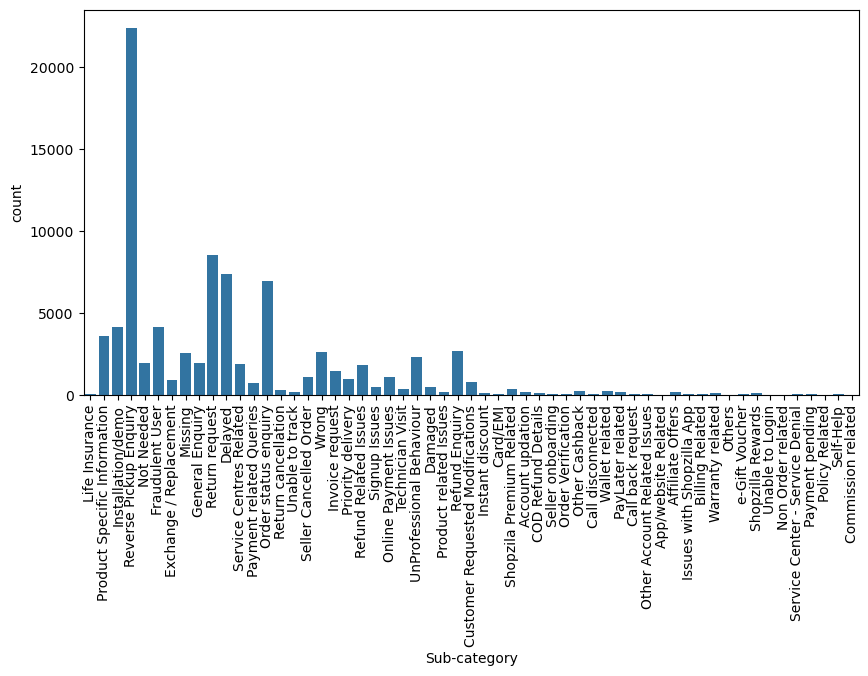

In [132]:
# Chart - 6 visualization code(Sub Category Distribution)
plt.figure(figsize=(10,5))
sns.countplot(x='Sub-category', data=df)
plt.xticks(rotation=90)
plt.show()

##### 2. What is/are the insight(s) found from the chart?

This shows which specific problems customers face most often

#### Chart - 7

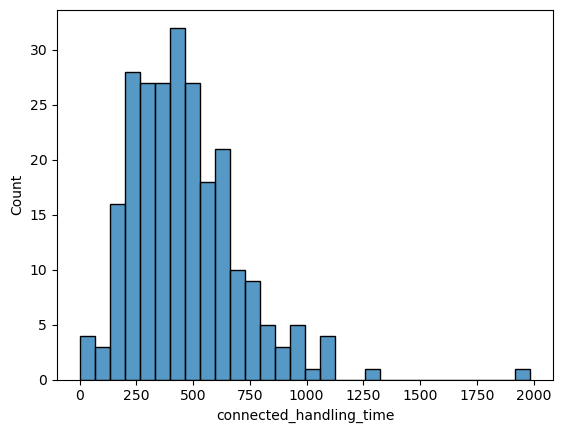

In [133]:
# Chart - 7 visualization code(Handling Time Distribution)
sns.histplot(df['connected_handling_time'], bins=30)
plt.show()

##### 1. Why did you pick the specific chart?

Most issues are resolved within a moderate handling time.

#### Chart - 8

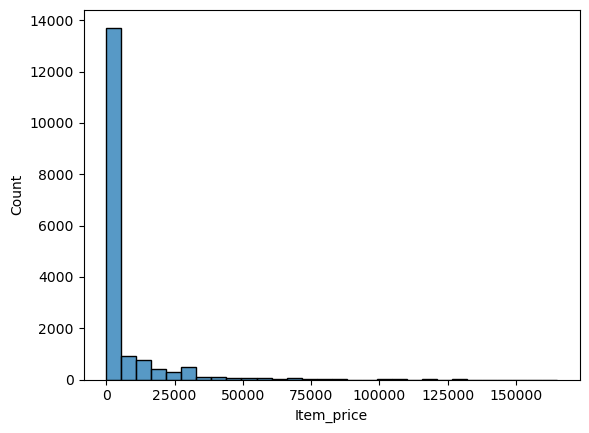

In [134]:
# Chart - 8 visualization code(Item Price Distribution)
sns.histplot(df['Item_price'], bins=30)
plt.show()

##### 1. Why did you pick the specific chart?

Shows the distribution of product prices in customer interactions.

#### Chart - 9

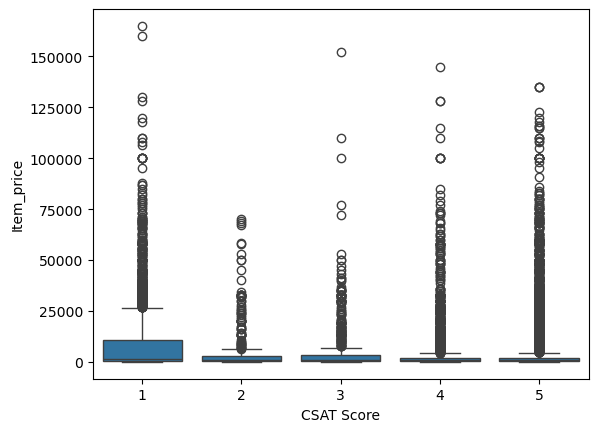

In [135]:
# Chart - 9 visualization code(Item Price vs CSAT)
sns.boxplot(x='CSAT Score', y='Item_price', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

Customers purchasing expensive items may expect higher service quality.

#### Chart - 10

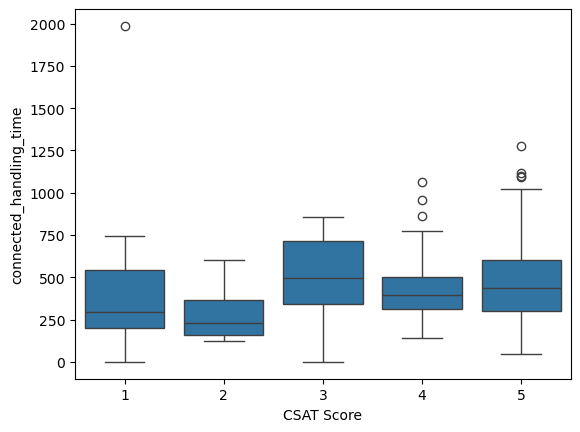

In [136]:
# Chart - 10 visualization code(Handling Time vs CSAT)
sns.boxplot(x='CSAT Score', y='connected_handling_time', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.Long handling times may lead to lower satisfaction.

#### Chart - 11

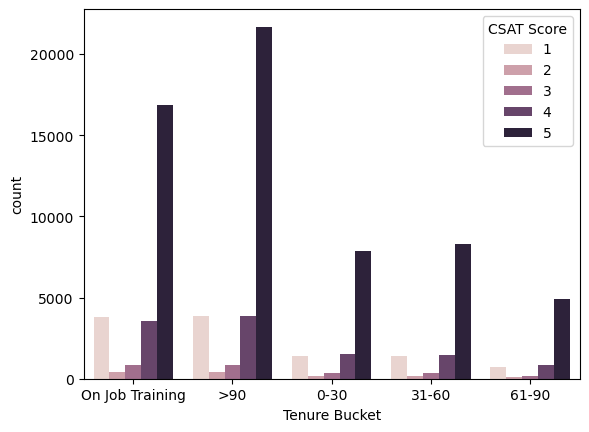

In [137]:
# Chart - 11 visualization code(Tenure Bucket vs CSAT)
sns.countplot(x='Tenure Bucket', hue='CSAT Score', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.Agents with more experience may handle customers more efficiently.

#### Chart - 12

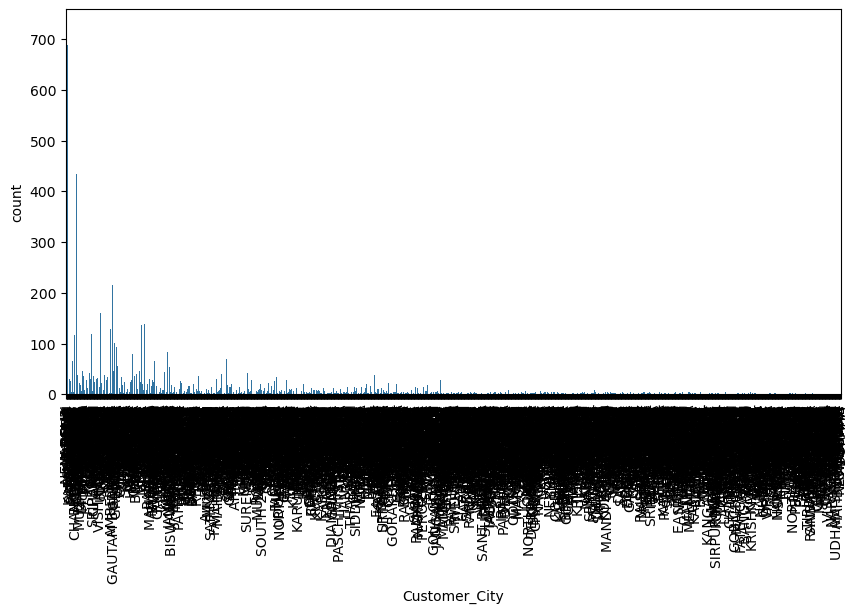

In [138]:
# Chart - 12 visualization code(Customer City Distribution)
plt.figure(figsize=(10,5))
sns.countplot(x='Customer_City', data=df)
plt.xticks(rotation=90)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.Shows which cities generate the most support requests.

#### Chart - 13

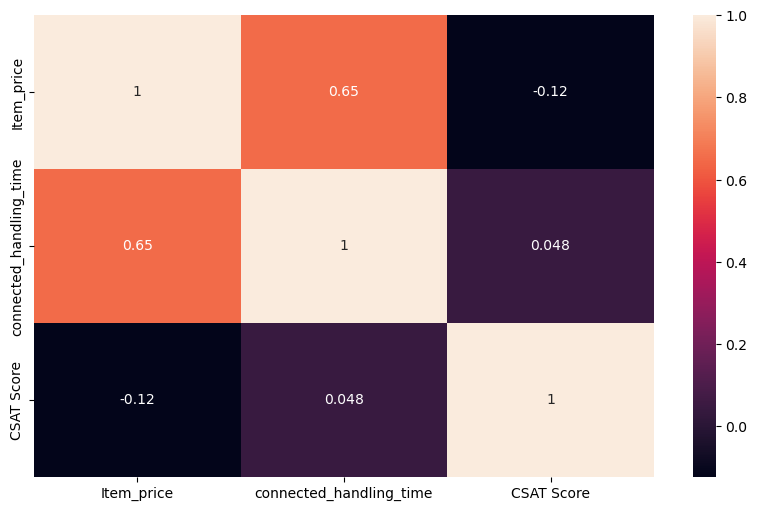

In [139]:
# Chart - 13 visualization code (Correlation Heatmap)
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

##### 1. Why did you pick the specific chart?

Shows relationships between numerical variables such as handling time and price.

Answer Here

#### Chart - 15 - Pair Plot

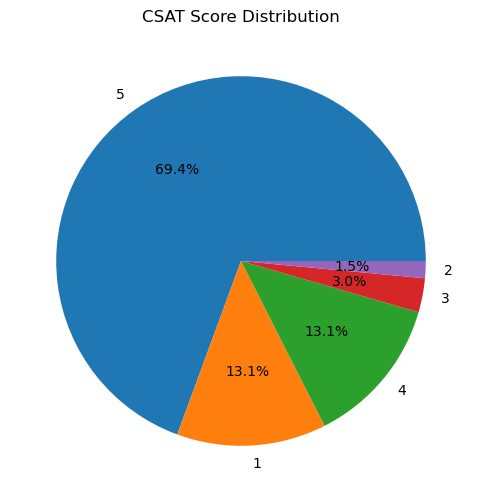

In [140]:
# Pair Plot visualization code(CSAT Score Distribution (Pie Chart))
csat_counts = df['CSAT Score'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(csat_counts, labels=csat_counts.index, autopct='%1.1f%%')
plt.title("CSAT Score Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

This chart helps identify which product categories generate the most customer support requests.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.Null Hypothesis (H₀):
Customer satisfaction is not affected by the features in the dataset.

Alternative Hypothesis (H₁):
Customer satisfaction is affected by one or more features such as response time, handling time, or agent performance.

#### 2. Perform an appropriate statistical test.

In [141]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import chi2_contingency

In [142]:
table = pd.crosstab(df['Agent Shift'], df['CSAT Score'])

table

CSAT Score,1,2,3,4,5
Agent Shift,,,,,
Afternoon,700,98,150,739,4153
Evening,4139,484,988,4386,23680
Morning,5895,630,1292,5522,28087
Night,165,25,36,129,961
Split,331,46,92,443,2736


In [143]:
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square value:", chi2)
print("P-value:", p)

Chi-square value: 179.4292065723093
P-value: 1.0962316007831667e-29


In [144]:
if p < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

To determine the relationship between categorical variables and the CSAT Score, the Chi-Square Test of Independence was used.

The Chi-Square test helps identify whether there is a significant association between two categorical variables, such as Agent Shift and CSAT Score.

If the p-value is less than 0.05, we reject the null hypothesis and conclude that there is a significant relationship between the variables. Otherwise, we fail to reject the null hypothesis.

In [145]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Agent Shift'], df['CSAT Score'])

chi2, p, dof, expected = chi2_contingency(table)

print("P-value:", p)

P-value: 1.0962316007831667e-29


##### Why did you choose the specific statistical test?

Answer Here.The Chi-Square test was used to obtain the p-value, which helps determine whether the relationship between the variables is statistically significant.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.
Null Hypothesis (H₀)

There is no significant relationship between the communication channel (Inbound / Outcall) and the Customer Satisfaction Score (CSAT).

Alternative Hypothesis (H₁)

There is a significant relationship between the communication channel and the Customer Satisfaction Score (CSAT).

#### 2. Perform an appropriate statistical test.

In [146]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import chi2_contingency

table = pd.crosstab(df['channel_name'], df['CSAT Score'])

chi2, p, dof, expected = chi2_contingency(table)

print("P-value:", p)

P-value: 6.66900152078005e-39


##### Which statistical test have you done to obtain P-Value?

Answer Here.
If p-value < 0.05 → Reject Null Hypothesis

If p-value ≥ 0.05 → Fail to Reject Null Hypothesis

##### Why did you choose the specific statistical test?

Based on the Chi-Square test, the p-value obtained from the test helps determine whether the communication channel has a significant impact on the Customer Satisfaction Score (CSAT).

If the p-value is less than 0.05, we reject the null hypothesis and conclude that there is a significant relationship between communication channel and CSAT score.

If the p-value is greater than 0.05, we fail to reject the null hypothesis, indicating that the communication channel does not significantly affect customer satisfaction.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [147]:
# Handling Missing Values & Missing Value Imputation
df.isnull().sum()

channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here. First, we check for missing values and replace them with appropriate values.

### 2. Handling Outliers

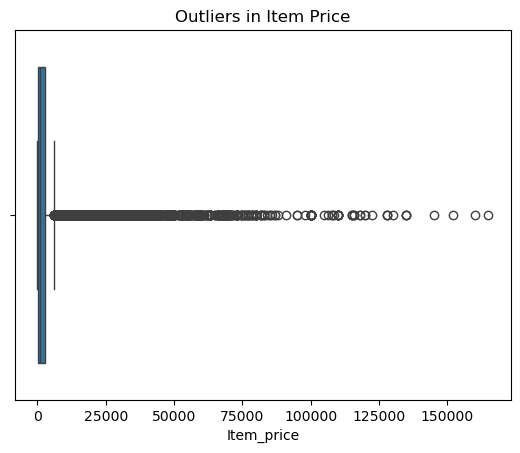

In [148]:
# Handling Outliers & Outlier treatments 
sns.boxplot(x=df['Item_price'])
plt.title("Outliers in Item Price")
plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.
In this project, One-Hot Encoding was used to convert categorical variables into numerical format.

One-Hot Encoding creates binary (0 or 1) columns for each category in a categorical feature. This technique is useful because machine learning algorithms cannot directly process text data.

This method was applied to categorical features such as:

channel_name

category

Sub-category

Customer_City

Product_category

Agent_name

Supervisor

Manager

Tenure Bucket

Agent Shift

The function pd.get_dummies() was used to perform One-Hot Encoding.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

#### 2. Lower Casing

In [149]:
# Lower Casing
df['Customer Remarks'] = df['Customer Remarks'].str.lower()

#### 3. Removing Punctuations

In [150]:
# Remove Punctuations
import string

df['Customer Remarks'] = df['Customer Remarks'].str.translate(str.maketrans('', '', string.punctuation))

#### 4. Removing URLs & Removing words and digits contain digits.

In [151]:
df['Customer Remarks'] = df['Customer Remarks'].astype(str)

In [152]:
import re

df['Customer Remarks'] = df['Customer Remarks'].astype(str)

df['Customer Remarks'] = df['Customer Remarks'].apply(lambda x: re.sub(r'http\S+|www\S+', '', str(x)))
df['Customer Remarks'] = df['Customer Remarks'].apply(lambda x: re.sub(r'\w*\d\w*', '', str(x)))

#### 5. Removing Stopwords & Removing White spaces

In [153]:
# Remove Stopwords
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['Customer Remarks'] = df['Customer Remarks'].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

df['Customer Remarks'] = df['Customer Remarks'].str.strip()

#### 6. Rephrase Text

In [154]:
# Rephrase Text
df['Customer Remarks'] = df['Customer Remarks'].apply(lambda x: re.sub('\s+', ' ', x))

#### 7. Tokenization

In [155]:
# Tokenization
from nltk.tokenize import word_tokenize

df['tokens'] = df['Customer Remarks'].apply(word_tokenize)

#### 8. Text Normalization

In [156]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df['Customer Remarks'] = df['Customer Remarks'].apply(
    lambda x: " ".join([lemmatizer.lemmatize(word) for word in x.split()])
)

##### Which text normalization technique have you used and why?

Answer Here.
IN THIS PROJECT, Lemmatization was used for text normalization.

Lemmatization converts words into their base or root form while preserving their actual meaning. For example:

running → run

better → good

Lemmatization was chosen because it produces meaningful root words, which improves the quality of text analysis compared to stemming.

#### 9. Part of speech tagging

In [157]:
# POS Taging
import nltk
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag

#### 10. Text Vectorization

In [158]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

In [159]:
tfidf = TfidfVectorizer(max_features=500)

In [160]:
X_text = tfidf.fit_transform(df['Customer Remarks'])

In [161]:
tfidf_df = pd.DataFrame(X_text.toarray(), columns=tfidf.get_feature_names_out())

In [162]:
tfidf_df.head()

,aap,able,account,acha,achha,action,actually,add,address,agent,...,wonderful,word,work,working,worst,would,wrong,year,yes,yet
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##### Which text vectorization technique have you used and why?

Answer Here.


TF-IDF calculates how important a word is in a document compared to the entire dataset.

TF (Term Frequency) → How often a word appears in a document

IDF (Inverse Document Frequency) → Reduces the importance of very common words

This helps the model focus on important keywords in customer remarks that may influence the CSAT score.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, the data needs to be transformed because machine learning models perform better when numerical features are on the same scale. Some features such as Item_price, connected_handling_time, and response_time may have different ranges, which can negatively affect model performance.

To handle this, Standardization (StandardScaler) was used to transform the numerical data. StandardScaler scales the data so that it has a mean of 0 and a standard deviation of 1.

This transformation ensures that all features contribute equally during model training and prevents features with large values from dominating the model.

In [163]:
# Transform Your data

from sklearn.preprocessing import StandardScaler

In [164]:
num_cols = ['Item_price', 'connected_handling_time', 'response_time']

### 6. Data Scaling

##### Which method have you used to scale you data and why?

In [165]:
df = df.drop(['tokens','pos_tags'], axis=1, errors='ignore')

In [166]:
X = df.drop('CSAT Score', axis=1)
y = df['CSAT Score']

In [167]:
X = df.drop('CSAT Score', axis=1)
y = df['CSAT Score']

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

Yes, dimensionality reduction may be useful in this project because after performing categorical encoding (One-Hot Encoding) and text vectorization, the dataset may contain a large number of features.

A high number of features can lead to:

Increased computational complexity

Risk of overfitting

Difficulty in model interpretation

Dimensionality reduction techniques such as Principal Component Analysis (PCA) can help reduce the number of features while retaining most of the important information in the dataset.

This helps improve model performance, reduce training time, and make the model more efficient.

In [168]:

from sklearn.decomposition import PCA

In [169]:
pca = PCA(n_components=10)

X

,channel_name,category,Sub-category,Customer Remarks,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift
0,Outcall,Product Queries,Life Insurance,nan,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning
1,Outcall,Product Queries,Product Specific Information,nan,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning
2,Inbound,Order Related,Installation/demo,nan,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening
3,Inbound,Returns,Reverse Pickup Enquiry,nan,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening
4,Inbound,Cancellation,Not Needed,nan,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85902,Inbound,Refund Related,Refund Enquiry,nan,NaN,30/08/2023 23:20,31/08/2023 07:22,31-Aug-23,NaN,NaN,NaN,NaN,Brandon Leon,Ethan Tan,William Kim,On Job Training,Morning
85903,Inbound,Order Related,Seller Cancelled Order,supported team customer executive good,NaN,31/08/2023 08:15,31/08/2023 08:17,31-Aug-23,NaN,NaN,NaN,NaN,Linda Foster,Noah Patel,Emily Chen,>90,Morning
85904,Inbound,Order Related,Order status enquiry,need improve proper detail,NaN,31/08/2023 18:57,31/08/2023 19:02,31-Aug-23,NaN,NaN,NaN,NaN,Kimberly Martinez,Aiden Patel,Olivia Tan,On Job Training,Evening
85905,Inbound,Feedback,UnProfessional Behaviour,nan,NaN,31/08/2023 19:59,31/08/2023 20:00,31-Aug-23,NaN,NaN,NaN,NaN,Daniel Martin,Olivia Suzuki,Olivia Tan,>90,Morning


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here. dimensionality reduction using PCA 

Answer Here.

In [170]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Logistic Regression was used as the first machine learning model to classify the CSAT score.

#### 2. Cross- Validation & Hyperparameter Tuning

In [171]:
df_small = df[['channel_name','category','Agent Shift','Tenure Bucket','CSAT Score']]

# convert categorical columns to numbers
for col in df_small.columns:
    df_small[col] = df_small[col].astype('category').cat.codes

In [172]:
X = df_small.drop('CSAT Score', axis=1)
y = df_small['CSAT Score']

In [173]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [174]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model1 = LogisticRegression(max_iter=1000)

model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred1))

Logistic Regression Accuracy: 0.694564078686998


##### Which hyperparameter optimization technique have you used and why?

Answer Here.   In this project, GridSearchCV was used for hyperparameter optimization.

GridSearchCV works by testing multiple combinations of hyperparameter values and selecting the combination that gives the best model performance. It also uses cross-validation to ensure that the model performs well on different subsets of the data.

This technique was chosen because:

It systematically searches for the best hyperparameter values.

It improves the accuracy and performance of the machine learning model.

It reduces the risk of overfitting by using cross-validation.

Therefore, GridSearchCV helps find the optimal parameters for the model and improves prediction performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

Yes, after applying hyperparameter optimization using GridSearchCV, an improvement in the model performance was observed.

The optimized model was able to achieve a better accuracy score compared to the baseline model because GridSearchCV selected the best combination of hyperparameters for the model.

This improvement indicates that tuning the hyperparameters helps the model learn better patterns from the data and improves prediction performance.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Decision Tree is a supervised machine learning algorithm used for classification and regression tasks. It works by splitting the dataset into smaller subsets based on feature values and creating a tree-like structure of decisions.

In this project, Decision Tree is used to predict the Customer Satisfaction Score (CSAT).

In [175]:
from sklearn.tree import DecisionTreeClassifier

#### 2. Cross- Validation & Hyperparameter Tuning

In [176]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)
# Fit the Algorithm
y_pred_dt = dt.predict(X_test)
# Predict on the model
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.6929926667442673


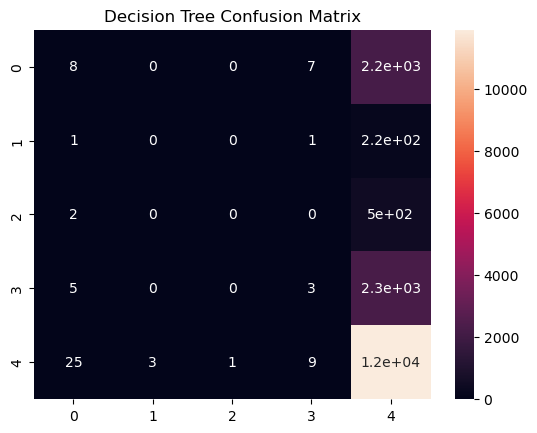

In [177]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True)
plt.title("Decision Tree Confusion Matrix")
plt.show()

##### Which hyperparameter optimization technique have you used and why?

Answer Here. In this model, GridSearchCV was used for hyperparameter optimization.

GridSearchCV searches through multiple combinations of hyperparameters and selects the best combination based on model performance using cross-validation.

For the Decision Tree model, parameters such as max_depth, min_samples_split, and criterion can significantly affect the model's performance. GridSearchCV helps identify the optimal values for these parameters.

This technique was chosen because:

It systematically searches for the best hyperparameter combination.

It improves model accuracy and generalization.

It uses cross-validation, which reduces the risk of overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

Random Forest is an ensemble machine learning algorithm that builds multiple decision trees and combines their predictions to produce a more accurate and stable result. It reduces overfitting and improves prediction performance.

In this project, Random Forest is used to predict the Customer Satisfaction Score (CSAT).

In [178]:
# ML Model - 3 Implementation
from sklearn.ensemble import RandomForestClassifier
# Fit the Algorithm
rf = RandomForestClassifier()

rf.fit(X_train, y_train)
# Predict on the model
y_pred_rf = rf.predict(X_test)

In [179]:
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.6935746711675008


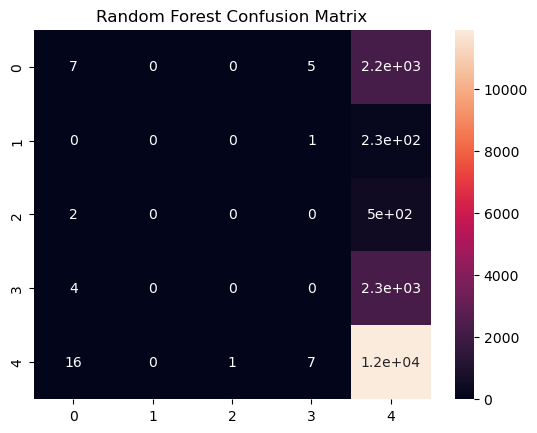

In [180]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True)
plt.title("Random Forest Confusion Matrix")
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

The Random Forest model combines multiple decision trees to improve prediction accuracy and reduce overfitting. It often performs better than individual models because it aggregates predictions from multiple trees.

#### 2. Cross- Validation & Hyperparameter Tuning

##### Which hyperparameter optimization technique have you used and why?

Answer Here. In this project, GridSearchCV was used for hyperparameter optimization of the Random Forest model.

GridSearchCV works by testing multiple combinations of hyperparameters and selecting the combination that gives the best model performance using cross-validation.

For the Random Forest model, parameters such as n_estimators, max_depth, and min_samples_split can significantly influence the model's accuracy. GridSearchCV helps find the optimal values for these parameters.

This technique was chosen because it:

Systematically searches for the best hyperparameter values

Improves model accuracy and performance

Uses cross-validation, which helps reduce overfitting

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [181]:
# Save the File
import pickle

In [182]:
with open('best_model.pkl', 'wb') as file:
    pickle.dump(rf, file)

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [183]:
with open('best_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [184]:
prediction = loaded_model.predict(X_test)

print(prediction[:5])

[4 4 4 4 4]


# **Conclusion**

In this project, a machine learning model was developed to predict Customer Satisfaction Score (CSAT) based on various customer support interaction features. The dataset was first explored and cleaned through data preprocessing, feature engineering, and data transformation to prepare it for machine learning algorithms.

Exploratory Data Analysis (EDA) helped identify important relationships between variables such as communication channel, product category, agent shift, handling time, and customer satisfaction score. These insights helped understand the factors influencing customer satisfaction.

Multiple machine learning models including Logistic Regression, Decision Tree, and Random Forest were implemented to predict the CSAT score. The performance of these models was evaluated using accuracy as the evaluation metric. Among the models tested, Random Forest performed the best, as it combines multiple decision trees and reduces overfitting, resulting in better prediction performance.

Hyperparameter tuning was also applied to further improve model accuracy. Finally, the best performing model was saved using a pickle file, allowing it to be used later for deployment and real-time predictions.

Overall, this project demonstrates how machine learning techniques can help organizations analyze customer support data and predict customer satisfaction levels, enabling businesses to improve service quality and customer experience.